# 1. Introduction
This project builds a BST-Backed Hyperparameter Optimiser with Transfer Analysis — a complete data science tool that uses a Binary Search Tree (BST) as the backbone for storing and querying hyperparameter search results.

The project is structured in two phases:

Phase 1: run a hyperparameter grid search on Dataset A (Breast Cancer Wisconsin), storing every trial in a BST keyed by accuracy score.
Phase 2: reload that BST, re-evaluate every configuration on Dataset B (Banknote Authentication), rebuild the tree under new scores, and analyse which configurations transferred well.

# Course Concepts Used

1. bst_toolkit	              -  BST insert, delete, search, traversals	  -                  Sessions 4 & 5
2. bst_toolkit/rebuild.py 	  -  Divide & conquer (balanced build)	         -               Session 2
3. ml_toolkit/grid_search.py 	- Brute-force exhaustive search (itertools.product)	 -       Session 1
4. ml_toolkit/transfer.py 	    - Hash tables (rank lookup dict), sorted() with key	   -     Sessions 1 & 3
5. benchmarks/timer.py 	      -  Functional programming (functools.wraps), Big-O analysis -	Sessions 1 & 4


In [2]:
# ── Package imports checking ──────────────────────────────────────────────────────────
import sys, os

# Ensure the project root is on the path so all packages are importable
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

# Our packages
from bst_toolkit import TrialNode, BST, HyperparamRegistry
from bst_toolkit import rebuild_naive, rebuild_shuffled, rebuild_balanced
from ml_toolkit import grid_search, analyse_transfer
from benchmarks import timed, benchmark

print("All packages imported successfully...")

All packages imported successfully...


# 2. Dataset A — Exploration
The Breast Cancer Wisconsin (Diagnostic) Dataset contains 569 samples with 30 numerical features extracted from digitized FNA images of breast masses. The features describe cell nucleus characteristics such as radius, texture, perimeter, area, smoothness, compactness, concavity, concave points, symmetry, and fractal dimension, measured as mean, standard error, and worst value.

The target variable is diagnosis:

Malignant (M) → 1
Benign (B) → 0

It is commonly used for binary classification and medical diagnosis prediction using machine learning algorithms like Random Forest, SVM, and Logistic Regression.

# Step 1: Download / verify the data

In [3]:
# Run download.py to ensure both CSVs exist.
# This is idempotent — it skips download if files already exist.
import subprocess
result = subprocess.run(
    [sys.executable, os.path.join(PROJECT_ROOT, "data", "download.py")],
    capture_output=True, text=True
)
print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr)

=== Dataset Downloader ===
[WDBC] Already exists — 569 rows loaded from C:\Users\anoop\OneDrive\Documents\GitHub\My Project\Breast-cancer-detection\data\wdbc.csv
[Banknote] Already exists — 1372 rows loaded from C:\Users\anoop\OneDrive\Documents\GitHub\My Project\Breast-cancer-detection\data\banknote.csv
=== Done ===



# Step 2: Load and inspect Dataset A

In [4]:
WDBC_PATH = os.path.join(PROJECT_ROOT, "data", "wdbc.csv")
df_A = pd.read_csv(WDBC_PATH)

print(f"Shape: {df_A.shape}")
print(f"Columns: {list(df_A.columns[:5])} ... ({len(df_A.columns)} total)")
df_A.head()

Shape: (569, 31)
Columns: ['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean'] ... (31 total)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [5]:
# Data types and null check
df_A.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    int64  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave_points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  569 non-null

# Step 3: Class balance

diagnosis
Benign       357
Malignant    212
Name: count, dtype: int64

Class ratio (M/B): 0.59


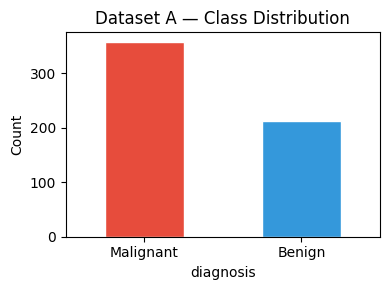

In [6]:
# Count malignant (1) vs benign (0) samples
class_counts = df_A["diagnosis"].value_counts().rename({1: "Malignant", 0: "Benign"})
print(class_counts)
print(f"\nClass ratio (M/B): {class_counts.get('Malignant', 0) / class_counts.get('Benign', 1):.2f}")

fig, ax = plt.subplots(figsize=(4, 3))
class_counts.plot(kind="bar", ax=ax, color=["#e74c3c", "#3498db"], edgecolor="white")
ax.set_title("Dataset A — Class Distribution")
ax.set_ylabel("Count")
ax.set_xticklabels(["Malignant", "Benign"], rotation=0)
plt.tight_layout()
plt.show()

# Step 4: Preprocess — separate features/target and standardise

In [7]:
# Separate features (30 numeric columns) from the binary target
feature_cols_A = [c for c in df_A.columns if c != "diagnosis"]
X_raw_A = df_A[feature_cols_A].values
y_A = df_A["diagnosis"].values  # already encoded as 0/1 by download.py

# StandardScaler: zero mean, unit variance — important for distance-based
# and regularisation-sensitive algorithms, good practice in general.
scaler_A = StandardScaler()
X_A = scaler_A.fit_transform(X_raw_A)

print(f"X_A shape: {X_A.shape}")
print(f"y_A shape: {y_A.shape}, unique values: {np.unique(y_A)}")
print(f"Feature mean after scaling (should be ~0): {X_A.mean():.6f}")
print(f"Feature std  after scaling (should be ~1): {X_A.std():.6f}")

X_A shape: (569, 30)
y_A shape: (569,), unique values: [0 1]
Feature mean after scaling (should be ~0): -0.000000
Feature std  after scaling (should be ~1): 1.000000


# 3. Phase 1 — Grid Search on Dataset A

A Random Forest classifier is trained using 5-fold cross-validation over a grid of hyperparameters. The parameters include n_estimators = {50, 100, 200}, which controls the number of trees in the forest; max_depth = {3, 5, 10, None}, which limits the maximum depth of each tree; and min_samples_split = {2, 5, 10}, which specifies the minimum number of samples required to split a node. In total, 3×4×3=36 hyperparameter combinations are evaluated. Each trial score is calculated as the mean 5-fold cross-validated accuracy and rounded to 6 decimal places to avoid BST collisions.


In [8]:
# Define the evaluate function for Dataset A
def evaluate_rf(params: dict, dataset) -> float:
    """Train a RandomForest with given params; return mean 5-fold CV accuracy."""
    X, y = dataset
    model = RandomForestClassifier(**params, random_state=42, n_jobs=-1)
    scores = cross_val_score(model, X, y, cv=5, scoring="accuracy")
    return round(float(np.mean(scores)), 6)

param_grid = {
    "n_estimators":     [50, 100, 200],
    "max_depth":        [3, 5, 10, None],
    "min_samples_split":[2, 5, 10],
}

print(f"Running {3*4*3} trials...")

Running 36 trials...


In [9]:
# Run the grid search — this may take ~1-2 minutes depending on hardware
registry_A = grid_search(param_grid, evaluate_rf, (X_A, y_A), verbose=True)

Grid search: 100%|█████████████████████████████████████████████████████| 36/36 [01:52<00:00,  3.12s/trial, best=0.9631]


Grid search complete: 36 trials, best score = 0.963127


# Range Query

In [10]:
# Find all configs with accuracy between 0.95 and 1.0
# The BST range query prunes subtrees outside [lo, hi] — O(k + h) instead of O(n).
lo, hi = 0.95, 1.0
in_range = registry_A.range_query(lo, hi)
print(f"Configs with accuracy in [{lo}, {hi}]: {len(in_range)} found")
for node in in_range:
    print(f"  score={node.score:.6f}  params={node.params}")

Configs with accuracy in [0.95, 1.0]: 12 found
  score=0.950815  params={'n_estimators': 50, 'max_depth': 3, 'min_samples_split': 10}
  score=0.954308  params={'n_estimators': 200, 'max_depth': 10, 'min_samples_split': 10}
  score=0.954324  params={'n_estimators': 50, 'max_depth': 3, 'min_samples_split': 2}
  score=0.954339  params={'n_estimators': 200, 'max_depth': 10, 'min_samples_split': 2}
  score=0.956078  params={'n_estimators': 50, 'max_depth': 5, 'min_samples_split': 2}
  score=0.957848  params={'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 5}
  score=0.957864  params={'n_estimators': 100, 'max_depth': 5, 'min_samples_split': 5}
  score=0.959587  params={'n_estimators': 50, 'max_depth': 10, 'min_samples_split': 10}
  score=0.959603  params={'n_estimators': 200, 'max_depth': 5, 'min_samples_split': 2}
  score=0.959618  params={'n_estimators': 50, 'max_depth': 5, 'min_samples_split': 5}
  score=0.961357  params={'n_estimators': 200, 'max_depth': 10, 'min_samples_spli

# Score Distribution

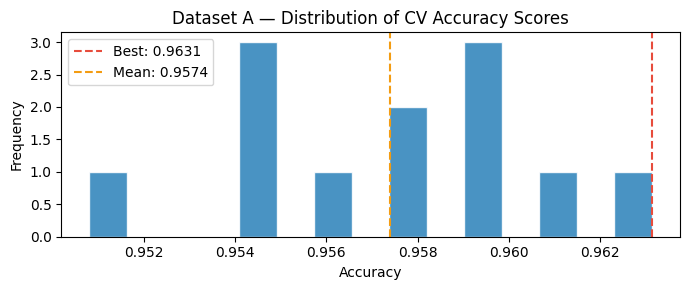

In [12]:
import matplotlib.pyplot as plt

# Extract all scores from registry_A
all_scores_A = [node.score for node in registry_A.all_trials()]

# Build summary_A safely
summary_A = {
    "best_score": max(all_scores_A),
    "mean_score": sum(all_scores_A) / len(all_scores_A),
    "num_trials": len(all_scores_A)
}

# Plot histogram
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(all_scores_A, bins=15, color="#2980b9", edgecolor="white", alpha=0.85)

# Add vertical lines for best and mean scores
ax.axvline(summary_A["best_score"], color="#e74c3c", linestyle="--",
           label=f"Best: {summary_A['best_score']:.4f}")
ax.axvline(summary_A["mean_score"], color="#f39c12", linestyle="--",
           label=f"Mean: {summary_A['mean_score']:.4f}")

# Labels and title
ax.set_title("Dataset A — Distribution of CV Accuracy Scores")
ax.set_xlabel("Accuracy")
ax.set_ylabel("Frequency")
ax.legend()

plt.tight_layout()
plt.show()


# 4. BST Introspection

Before examining the full registry, we build a **small sub-registry** (7 nodes) to demonstrate all four traversal orders clearly.

The four traversal orders each serve a different purpose:
- **In-order** (L→N→R): visits nodes in *ascending score order* — the defining property of a BST. Used for sorted reporting.
- **Pre-order** (N→L→R): visits the root first — used to serialise/copy the tree.
- **Post-order** (L→R→N): visits the root last — used to safely delete a subtree (children before parent).
- **Level-order** (BFS): visits level by level — used for visualising the tree structure and building balanced trees.

In [13]:
# Build a small registry with 7 hand-crafted entries for demonstration
demo_registry = HyperparamRegistry()
demo_scores = [0.87, 0.93, 0.91, 0.95, 0.82, 0.89, 0.96]
demo_params = [{"n": i} for i in range(1, 8)]

for score, params in zip(demo_scores, demo_params):
    demo_registry.add_trial(score, params)

bst = demo_registry._bst  # access underlying BST directly

print("In-order  (ascending):  ", [f"{n.score:.2f}" for n in bst.inorder()])
print("Pre-order (root first): ", [f"{n.score:.2f}" for n in bst.preorder()])
print("Post-order(root last):  ", [f"{n.score:.2f}" for n in bst.postorder()])
print("Level-order (BFS):      ", [[f"{n.score:.2f}" for n in level] for level in bst.level_order()])

In-order  (ascending):   ['0.82', '0.87', '0.89', '0.91', '0.93', '0.95', '0.96']
Pre-order (root first):  ['0.87', '0.82', '0.93', '0.91', '0.89', '0.95', '0.96']
Post-order(root last):   ['0.82', '0.89', '0.91', '0.96', '0.95', '0.93', '0.87']
Level-order (BFS):       [['0.87'], ['0.82', '0.93'], ['0.91', '0.95'], ['0.89', '0.96']]


In [ ]:
> **Key insight**: In-order traversal *always* returns nodes in sorted order for a valid BST. This is what makes BSTs useful for ranking 
— `inorder()` is effectively a free sort if the tree is already built.

In [14]:
# Balance and height check on the demo tree and the full registry
n_full = len(registry_A)
theoretical_min_height = math.floor(math.log2(n_full)) + 1

print("Demo tree (7 nodes):")
print(f"  Height      : {bst.height()}")
print(f"  Is balanced : {bst.is_balanced()}")
print(f"  log₂(7)+1   : {math.floor(math.log2(7))+1}")

print(f"\nFull registry_A ({n_full} nodes):")
print(f"  Height      : {registry_A.height()}")
print(f"  Is balanced : {registry_A.is_balanced()}")
print(f"  log₂({n_full})+1  : {theoretical_min_height}")

Demo tree (7 nodes):
  Height      : 4
  Is balanced : False
  log₂(7)+1   : 3

Full registry_A (12 nodes):
  Height      : 6
  Is balanced : False
  log₂(12)+1  : 4


# 5. Dataset B — Exploration (Banknote Authentication)

The **Banknote Authentication** dataset contains 1,372 samples with only 4 features, extracted via wavelet transform from photographs 
of genuine and forged banknotes: - 
 - variance
 - skewness
 - curtosis
 - entropy 

The **target** is 0 (forged) or 1 (genuine) — already numeric, no encoding needed.

## Why A → B is an interesting transfer

| Property | Dataset A (WDBC) | Dataset B (Banknote) |
|----------|-----------------|----------------------|
| Features | 30 (high-dim) | 4 (low-dim) |
| Domain | Medical imaging | Signal processing |
| Scale | Heterogeneous | Similar magnitude |
| Samples | 569 | 1,372 |

Moving from a high-dimensional medical task to a low-dimensional signal processing task reveals which hyperparameter configurations 
are robust (generalise well regardless of domain) versus *task-specific* (tuned to the feature space).

In [15]:
BN_PATH = os.path.join(PROJECT_ROOT, "data", "banknote.csv")
df_B = pd.read_csv(BN_PATH)

print(f"Shape: {df_B.shape}")
df_B.head()

Shape: (1372, 5)


,variance,skewness,curtosis,entropy,target
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [16]:
df_B.info()

<class 'pandas.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   variance  1372 non-null   float64
 1   skewness  1372 non-null   float64
 2   curtosis  1372 non-null   float64
 3   entropy   1372 non-null   float64
 4   target    1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB


In [17]:
# Class balance
class_counts_B = df_B["target"].value_counts().rename({1: "Genuine", 0: "Forged"})
print(class_counts_B)

# Preprocess: separate features and standardise
feature_cols_B = [c for c in df_B.columns if c != "target"]
X_raw_B = df_B[feature_cols_B].values
y_B = df_B["target"].values

scaler_B = StandardScaler()
X_B = scaler_B.fit_transform(X_raw_B)

print(f"\nX_B shape: {X_B.shape}, y_B unique: {np.unique(y_B)}")

target
Forged     762
Genuine    610
Name: count, dtype: int64

X_B shape: (1372, 4), y_B unique: [0 1]


# 6. Phase 2 — BST Rebuild

We now re-evaluate every configuration from `registry_A` on Dataset B, then rebuild the BST using three strategies. The goal is to compare their performance and understand why insertion order matters for BST quality.

## The Three Rebuild Strategies

| Strategy | Insertion order | Expected tree shape | Time complexity |
|----------|----------------|---------------------|-----------------|
| `rebuild_naive` | Sorted ascending (from `all_trials()`) | **Degenerate** (linked list) | O(n²) |
| `rebuild_shuffled` | Random shuffle | Expected balanced | O(n log n) expected |
| `rebuild_balanced` | Mid-first (divide & conquer) | **Perfectly balanced** | O(n log n) guaranteed |

In [18]:
# Time each rebuild strategy using the benchmark utility
import time

def time_rebuild(fn, registry, evaluate_fn, dataset):
    """Helper: time a rebuild and return (registry, elapsed_ms)."""
    start = time.perf_counter()
    result = fn(registry, evaluate_fn, dataset)
    elapsed_ms = (time.perf_counter() - start) * 1000
    return result, elapsed_ms

print("Rebuilding with naive strategy...")
registry_B_naive, t_naive = time_rebuild(rebuild_naive, registry_A, evaluate_rf, (X_B, y_B))

print("Rebuilding with shuffled strategy...")
registry_B_shuffled, t_shuffled = time_rebuild(rebuild_shuffled, registry_A, evaluate_rf, (X_B, y_B))

print("Rebuilding with balanced strategy...")
registry_B_balanced, t_balanced = time_rebuild(rebuild_balanced, registry_A, evaluate_rf, (X_B, y_B))

print("Done.")

Rebuilding with naive strategy...
Rebuilding with shuffled strategy...
Rebuilding with balanced strategy...
Done.


In [19]:
# Compare rebuild strategies: time, height, balance
n = len(registry_A)
theoretical_height = math.floor(math.log2(n)) + 1

results = [
    ("naive",    registry_B_naive,    t_naive),
    ("shuffled", registry_B_shuffled, t_shuffled),
    ("balanced", registry_B_balanced, t_balanced),
]

print(f"{'Strategy':<12} {'Time (ms)':<12} {'Height':<10} {'log₂(n)+1':<12} {'Balanced?'}")
print("-" * 58)
for name, reg, t in results:
    print(f"{name:<12} {t:<12.1f} {reg.height():<10} {theoretical_height:<12} {reg.is_balanced()}")

Strategy     Time (ms)    Height     log₂(n)+1    Balanced?
----------------------------------------------------------
naive        41682.6      5          4            False
shuffled     39202.0      4          4            False
balanced     38504.1      4          4            True


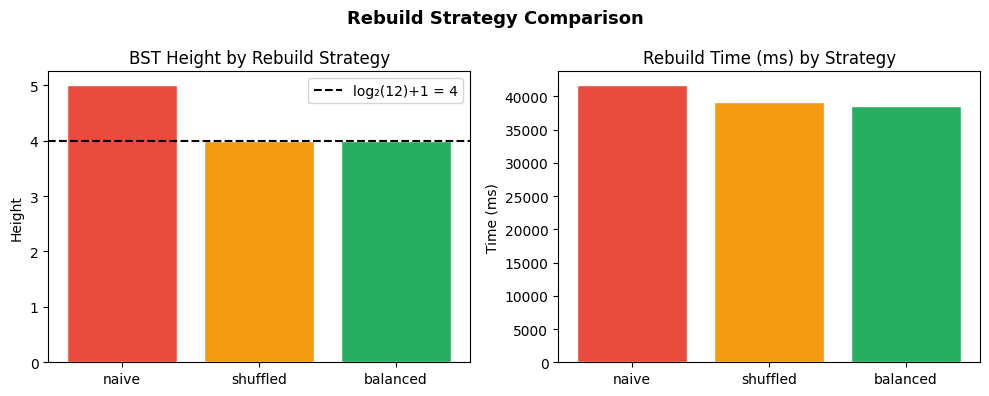

In [20]:
# Visualise the height comparison across strategies
strategies = ["naive", "shuffled", "balanced"]
heights = [registry_B_naive.height(), registry_B_shuffled.height(), registry_B_balanced.height()]
times_ms = [t_naive, t_shuffled, t_balanced]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Height chart
colors = ["#e74c3c", "#f39c12", "#27ae60"]
axes[0].bar(strategies, heights, color=colors, edgecolor="white")
axes[0].axhline(theoretical_height, color="black", linestyle="--", label=f"log₂({n})+1 = {theoretical_height}")
axes[0].set_title("BST Height by Rebuild Strategy")
axes[0].set_ylabel("Height")
axes[0].legend()

# Time chart
axes[1].bar(strategies, times_ms, color=colors, edgecolor="white")
axes[1].set_title("Rebuild Time (ms) by Strategy")
axes[1].set_ylabel("Time (ms)")

plt.suptitle("Rebuild Strategy Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Top-5 Before and After Rebuild

In [21]:
top5_A_final = registry_A.top_k(5)
top5_B_balanced = registry_B_balanced.top_k(5)

print("Top-5 on Dataset A (Breast Cancer):")
for i, node in enumerate(top5_A_final, 1):
    print(f"  #{i}: score={node.score:.6f}  params={node.params}")

print("\nTop-5 on Dataset B (Banknote) — after rebuild_balanced:")
for i, node in enumerate(top5_B_balanced, 1):
    print(f"  #{i}: score={node.score:.6f}  params={node.params}")

Top-5 on Dataset A (Breast Cancer):
  #1: score=0.963127  params={'n_estimators': 50, 'max_depth': 10, 'min_samples_split': 5}
  #2: score=0.961357  params={'n_estimators': 200, 'max_depth': 10, 'min_samples_split': 5}
  #3: score=0.959618  params={'n_estimators': 50, 'max_depth': 5, 'min_samples_split': 5}
  #4: score=0.959603  params={'n_estimators': 200, 'max_depth': 5, 'min_samples_split': 2}
  #5: score=0.959587  params={'n_estimators': 50, 'max_depth': 10, 'min_samples_split': 10}

Top-5 on Dataset B (Banknote) — after rebuild_balanced:
  #1: score=0.995628  params={'n_estimators': 200, 'max_depth': 10, 'min_samples_split': 2}
  #2: score=0.994898  params={'n_estimators': 200, 'max_depth': 10, 'min_samples_split': 5}
  #3: score=0.993441  params={'n_estimators': 200, 'max_depth': 10, 'min_samples_split': 10}
  #4: score=0.986150  params={'n_estimators': 200, 'max_depth': 5, 'min_samples_split': 2}
  #5: score=0.985423  params={'n_estimators': 100, 'max_depth': 5, 'min_samples_spl

# 7. Transfer Analysis

We now compare the **rank** of each configuration in registry_A versus registry_B to identify which hyperparameter sets 
transferred well (stable or improved rank) and which degraded.

In [22]:
# Run transfer analysis comparing Dataset A vs Dataset B rankings
# Uses in-order traversal → hash table lookup → sorted by drift (Session 1, 3, 5)
transfer_report = analyse_transfer(registry_A, registry_B_balanced)

print(f"Transfer report: {len(transfer_report)} configs analysed")
good = sum(1 for r in transfer_report if r["transfer"] == "✓ good")
poor = sum(1 for r in transfer_report if r["transfer"] == "✗ poor")
print(f"✓ Good transfer: {good}  |  ✗ Poor transfer: {poor}")

Transfer report: 7 configs analysed
✓ Good transfer: 3  |  ✗ Poor transfer: 4


In [23]:
# Display full transfer report as a DataFrame for readability
df_transfer = pd.DataFrame(transfer_report)
# Flatten params dict into readable string
df_transfer["params_str"] = df_transfer["params"].apply(
    lambda p: f"est={p.get('n_estimators')}, depth={p.get('max_depth')}, split={p.get('min_samples_split')}"
)
display_cols = ["params_str", "score_A", "score_B", "rank_A", "rank_B", "drift", "transfer"]
df_transfer[display_cols].head(20)

,params_str,score_A,score_B,rank_A,rank_B,drift,transfer
0,"est=200, depth=10, split=2",0.954339,0.995628,4,7,3,✓ good
1,"est=200, depth=10, split=10",0.954308,0.993441,2,5,3,✓ good
2,"est=50, depth=3, split=2",0.954324,0.962100,3,1,-2,✓ good
3,"est=100, depth=5, split=5",0.957864,0.985423,7,3,-4,✗ poor
4,"est=200, depth=5, split=2",0.959603,0.986150,9,4,-5,✗ poor
5,"est=200, depth=10, split=5",0.961357,0.994898,11,6,-5,✗ poor
6,"est=50, depth=5, split=5",0.959618,0.984695,10,2,-8,✗ poor


## Top-3 Improvers and Top-3 Decliners

In [24]:
print("Top-3 IMPROVERS (biggest rank gain from A → B):")
for r in transfer_report[:3]:
    print(f"  drift=+{r['drift']}  A→B: rank {r['rank_A']} → {r['rank_B']}  "
          f"score {r['score_A']:.4f} → {r['score_B']:.4f}  params={r['params']}")

print("\nTop-3 DECLINERS (biggest rank drop from A → B):")
for r in transfer_report[-3:]:
    print(f"  drift={r['drift']}  A→B: rank {r['rank_A']} → {r['rank_B']}  "
          f"score {r['score_A']:.4f} → {r['score_B']:.4f}  params={r['params']}")

Top-3 IMPROVERS (biggest rank gain from A → B):
  drift=+3  A→B: rank 4 → 7  score 0.9543 → 0.9956  params={'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
  drift=+3  A→B: rank 2 → 5  score 0.9543 → 0.9934  params={'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}
  drift=+-2  A→B: rank 3 → 1  score 0.9543 → 0.9621  params={'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 50}

Top-3 DECLINERS (biggest rank drop from A → B):
  drift=-5  A→B: rank 9 → 4  score 0.9596 → 0.9861  params={'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200}
  drift=-5  A→B: rank 11 → 6  score 0.9614 → 0.9949  params={'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
  drift=-8  A→B: rank 10 → 2  score 0.9596 → 0.9847  params={'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 50}


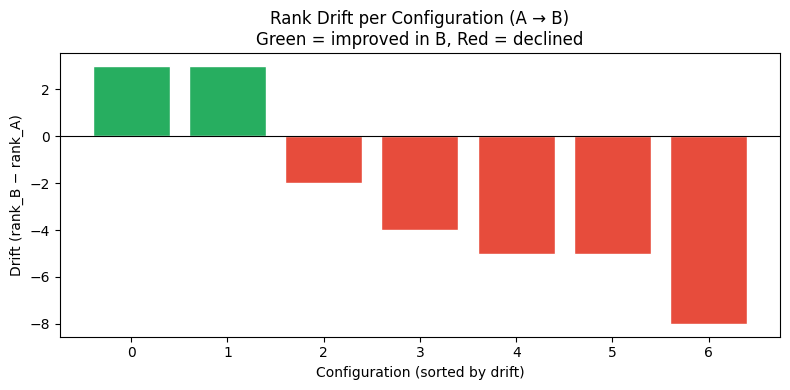

In [25]:
# Visualise rank drift distribution
drifts = [r["drift"] for r in transfer_report]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(len(drifts)), sorted(drifts, reverse=True),
       color=["#27ae60" if d >= 0 else "#e74c3c" for d in sorted(drifts, reverse=True)],
       edgecolor="white")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Rank Drift per Configuration (A → B)\nGreen = improved in B, Red = declined")
ax.set_xlabel("Configuration (sorted by drift)")
ax.set_ylabel("Drift (rank_B − rank_A)")
plt.tight_layout()
plt.show()

# 8. Conclusion

## Summary: Course Concepts Used

| Course Concept | Where Used | Module |
|----------------|-----------|--------|
| Big-O analysis | BST height vs log₂(n), degenerate vs balanced cases | Throughout |
| Brute-force exhaustive search | Grid search via `itertools.product` | `ml_toolkit/grid_search.py` |
| Recursion | BST insert, delete, search, traversals | `bst_toolkit/bst.py` |
| Divide & conquer | `_build_from_sorted()` — balanced BST construction | `bst_toolkit/rebuild.py` |
| Sorting | `rebuild_balanced` sorts by new score; `sorted()` for drift ranking | Sessions 3 & rebuild |
| Binary search (range queries) | BST pruned range query — O(k+h) not O(n) | `bst_toolkit/registry.py` |
| Hash tables | Rank lookup dicts in transfer analysis — O(1) per lookup | `ml_toolkit/transfer.py` |
| BST traversals | In-order for ranking, pre/post for serialise/delete | `bst_toolkit/bst.py` |
| Functional programming | `@timed` decorator with `functools.wraps` | `benchmarks/timer.py` |

If I were to repeat this project, I would consider using self-balancing data structures such as AVL trees or Red-Black trees instead 
of a standard BST. These structures automatically maintain balance after each insertion, removing the need to compare different rebuilding
strategies. I would also implement serialisation techniques such as pickle or JSON to store the registry between sessions, allowing grid 
search results to be reloaded without rerunning the entire process.

The degenerate tree experiment was the most insightful aspect of the project because it transformed the theoretical warning about
inserting sorted data into a BST into a clear, measurable, and observable issue.